## Import Library

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.load_data import load_data
from src.technical_indicators import technical_analysis
from src.financial_metrics import financial_metrics

## Load and prepare the data

In [3]:
data = load_data('../data/AAPL.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data.head(10)

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800
2009-01-09,2.716589,2.800564,2.703393,2.795466,546845600
2009-01-12,2.659007,2.728886,2.625717,2.712990,617716400
2009-01-13,2.630514,2.691395,2.589726,2.646409,798397600
2009-01-14,2.559135,2.616717,2.540840,2.586427,1021664000


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3774 non-null   float64
 1   High    3774 non-null   float64
 2   Low     3774 non-null   float64
 3   Open    3774 non-null   float64
 4   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB


## Apply Analysis Indicators with TA-Lib 

In [4]:
sma_20,ema_20,rsl,macd,macd_signal,macd_hist = technical_analysis(data['Close'])
ta_df = pd.DataFrame({"SMA_20": sma_20.index, "EMA_20":ema_20.index, "RSL":rsl.index, "MACD": macd.index, "MACD_Signal":macd_signal.index, "MACD_Hist": macd_hist.index})
ta_df.head(10)

,SMA_20,EMA_20,RSL,MACD,MACD_Signal,MACD_Hist
0,2009-01-02,2009-01-02,2009-01-02,2009-01-02,2009-01-02,2009-01-02
1,2009-01-05,2009-01-05,2009-01-05,2009-01-05,2009-01-05,2009-01-05
2,2009-01-06,2009-01-06,2009-01-06,2009-01-06,2009-01-06,2009-01-06
3,2009-01-07,2009-01-07,2009-01-07,2009-01-07,2009-01-07,2009-01-07
4,2009-01-08,2009-01-08,2009-01-08,2009-01-08,2009-01-08,2009-01-08
5,2009-01-09,2009-01-09,2009-01-09,2009-01-09,2009-01-09,2009-01-09
6,2009-01-12,2009-01-12,2009-01-12,2009-01-12,2009-01-12,2009-01-12
7,2009-01-13,2009-01-13,2009-01-13,2009-01-13,2009-01-13,2009-01-13
8,2009-01-14,2009-01-14,2009-01-14,2009-01-14,2009-01-14,2009-01-14
9,2009-01-15,2009-01-15,2009-01-15,2009-01-15,2009-01-15,2009-01-15


##  Financial Metrics

In [4]:
returns,cumulative_returns, volatility = financial_metrics(data['Close'])
volatility_percent = volatility* 100
print(f"Annualized Volatility(Measure of how risky) is: {volatility_percent:.2f}%")

Annualized Volatility(Measure of how risky) is: 28.59%


## Visualize Data

### Stock close price and moving averages

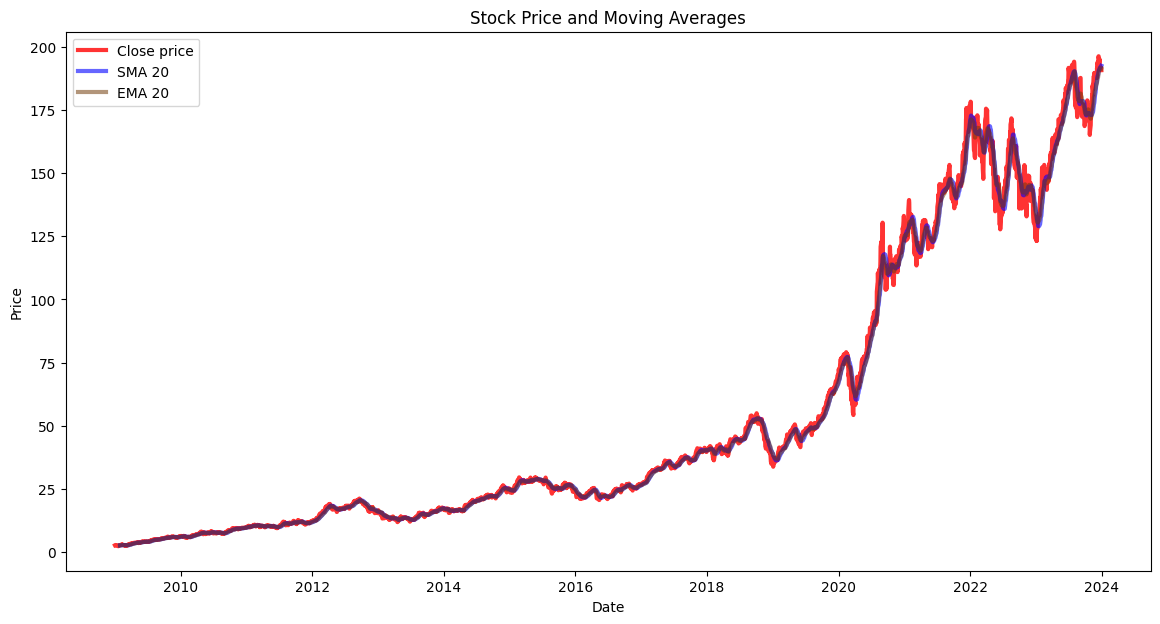

In [41]:
plt.figure(figsize=(14,7))
plt.plot(data['Close'], label='Close price', color='r', alpha=0.8, linewidth=3)
plt.plot(sma_20, label='SMA 20', color="b", alpha=0.6,linewidth=3)
plt.plot(ema_20, label='EMA 20', color="#70390688",linewidth=3)
plt.title('Stock Price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

### RSI Plot

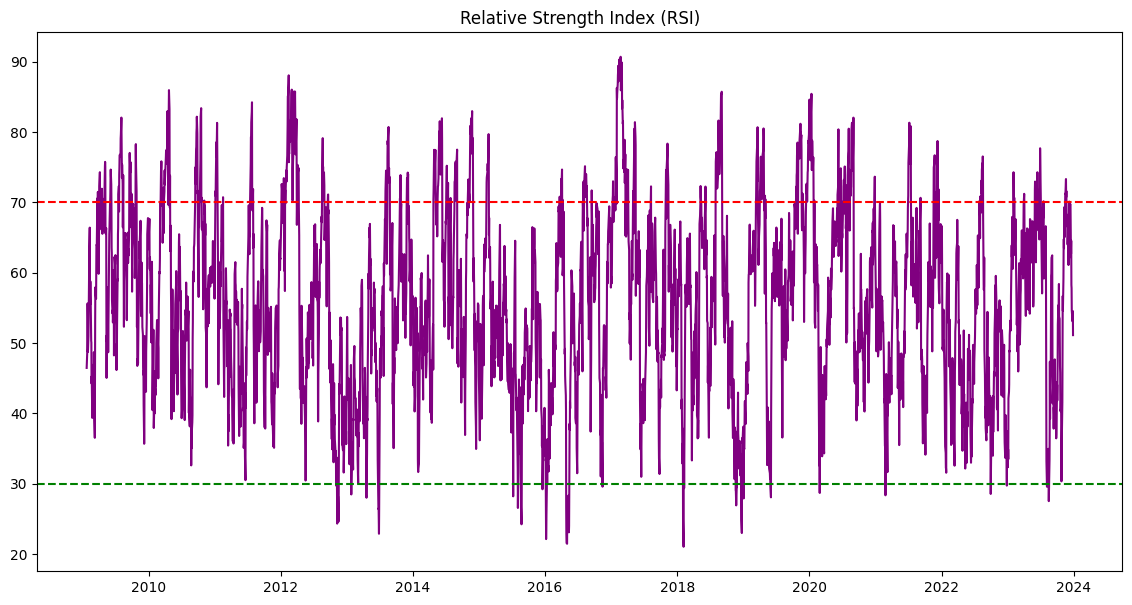

In [18]:
plt.figure(figsize=(14,7))
plt.plot(rsl, label='RSL', color='purple')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('Relative Strength Index (RSI)')
plt.show()

### Cumulative Returns

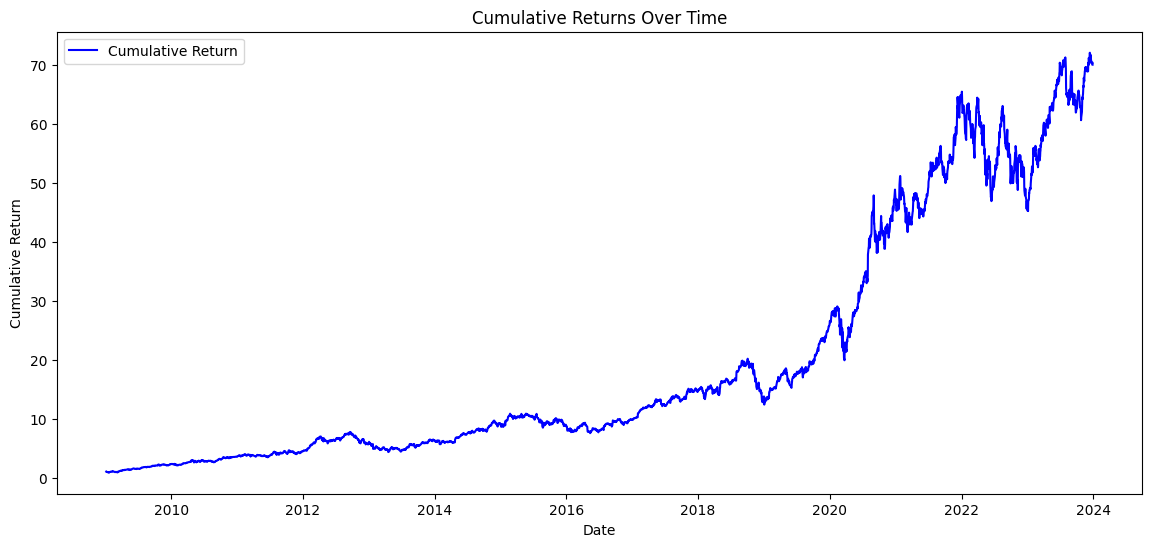

In [5]:
plt.figure(figsize=(14,6))
plt.plot(cumulative_returns, label='Cumulative Return', color='blue')
plt.title('Cumulative Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

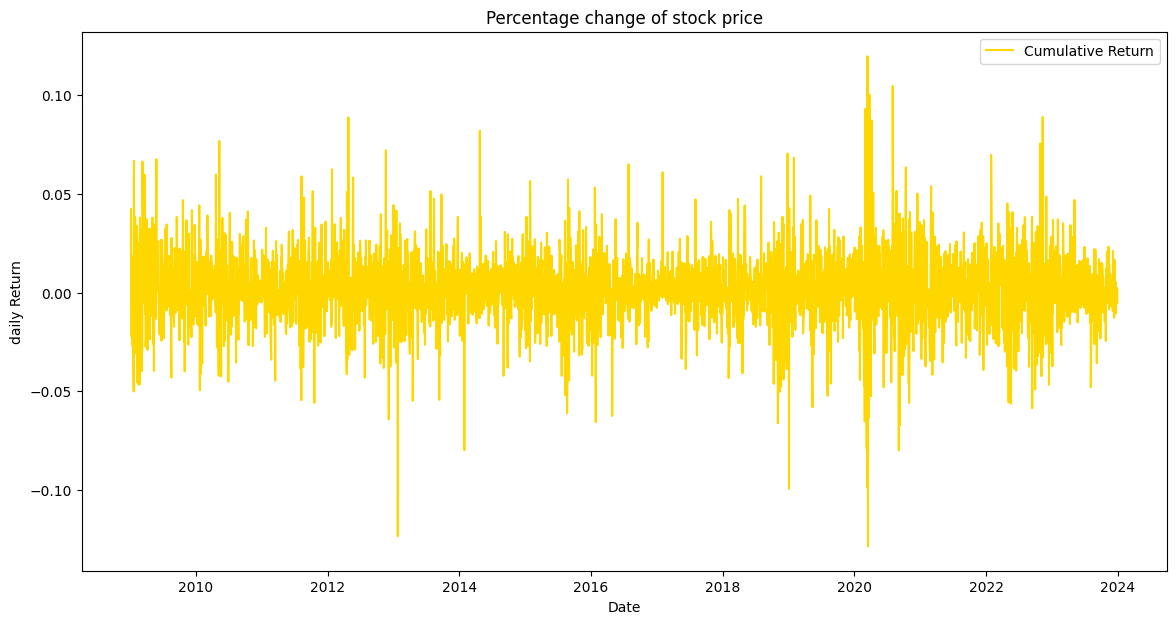

In [26]:
plt.figure(figsize=(14,7))
plt.plot(returns, label='Cumulative Return', color='gold')
plt.title('Percentage change of stock price')
plt.xlabel('Date')
plt.ylabel('daily Return')
plt.legend()
plt.show()

### Moving Average Convergence Divergence

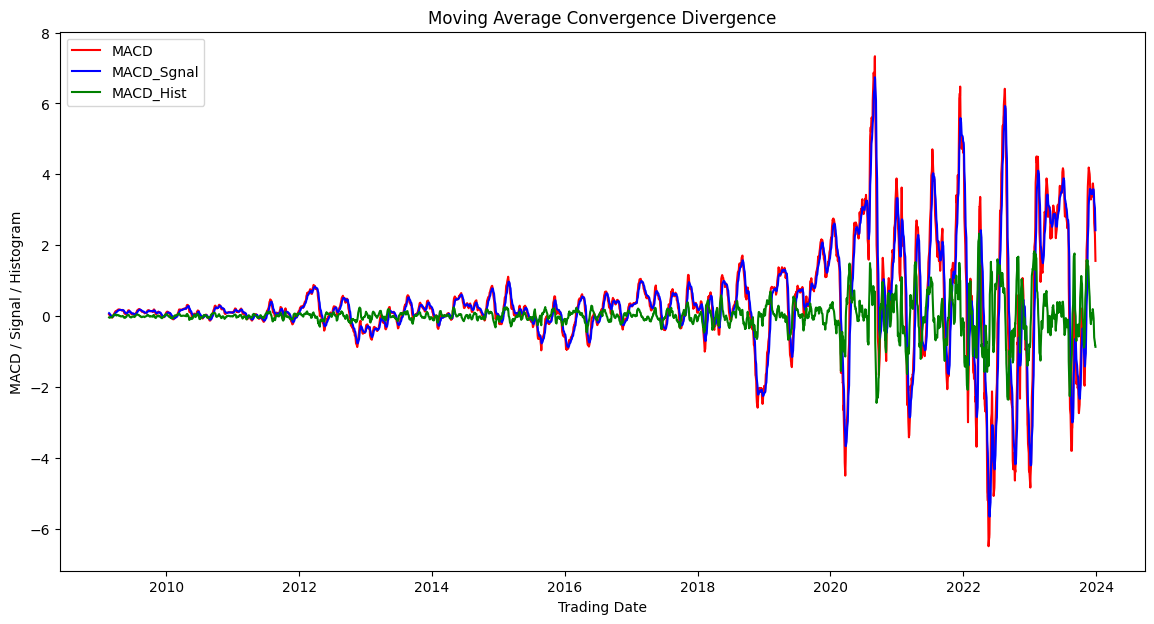

In [49]:
plt.figure(figsize=(14,7))
plt.plot(macd, label='MACD', color='r')
plt.plot(macd_signal, label='MACD_Sgnal', color="b" )
plt.plot(macd_hist, label='MACD_Hist', color="GREEN")
plt.title('Moving Average Convergence Divergence')
plt.xlabel('Trading Date')
plt.ylabel('MACD / Signal / Histogram')
plt.legend()
plt.show()